**AI Job Market Analysis: Predictive Modeling and Strategic Segmentation**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('/content/ai_job_market_insights.csv')

In [ ]:
df.head(5)
print("\nmissing values per column:")
print(df.isnull().sum())


missing values per column:
Job_Title                0
Industry                 0
Company_Size             0
Location                 0
AI_Adoption_Level        0
Automation_Risk          0
Required_Skills          0
Salary_USD               0
Remote_Friendly          0
Job_Growth_Projection    0
dtype: int64


**Exploratory Data Analysis(EDA)**

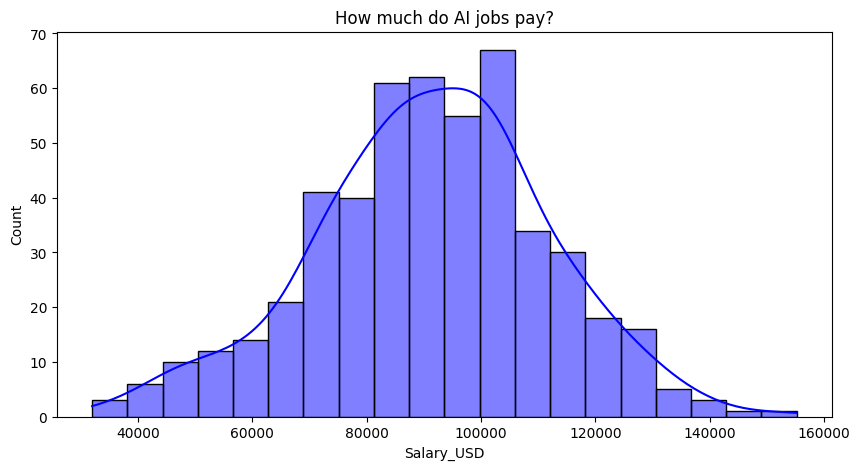

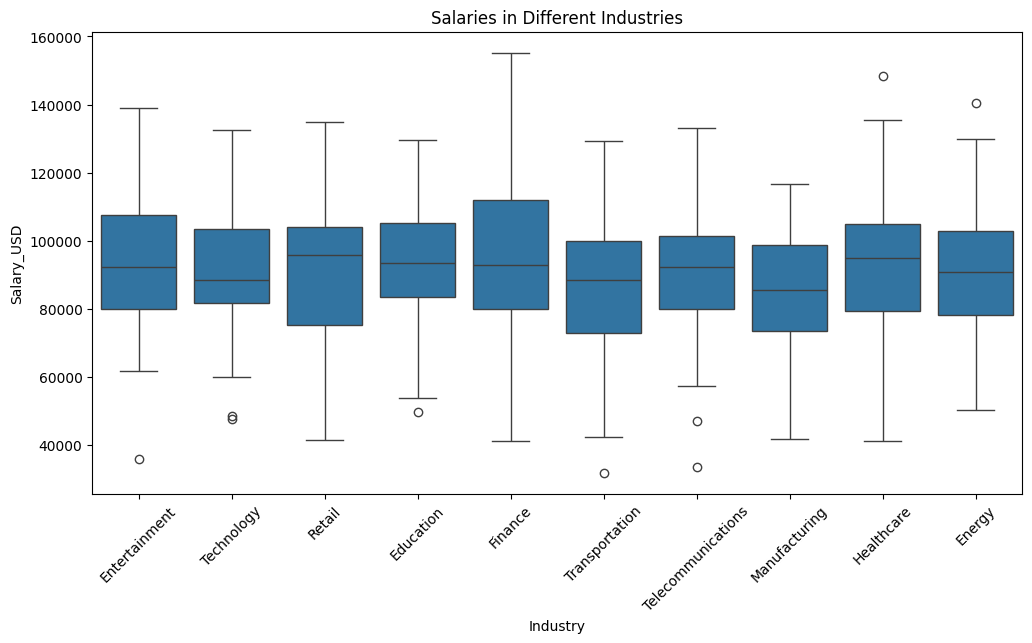

In [4]:
# Plot 1: Salary Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['Salary_USD'], kde=True, color='blue')
plt.title('How much do AI jobs pay?')
plt.show()

# Plot 2: Salary by Industry
plt.figure(figsize=(12, 6))
sns.boxplot(x='Industry', y='Salary_USD', data=df)
plt.xticks(rotation=45)
plt.title('Salaries in Different Industries')
plt.show()

**Preparing Data(Text to Numbers)**

In [5]:

df_model = df.drop(['Job_Title', 'Required_Skills'], axis=1)
df_encoded = pd.get_dummies(df_model)

# Define X (factors) and y (the target: Salary)
X = df_encoded.drop('Salary_USD', axis=1)
y = df_encoded['Salary_USD']

print(f"Number of columns after encoding: {X.shape[1]}")

Number of columns after encoding: 34


**Training the Prediction Model**

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict and Check Error
preds = model.predict(X_test)
print(f"Average Prediction Error: ${mean_absolute_error(y_test, preds):.2f}")

Average Prediction Error: $19050.99


**Market Tiers (Clustering)**

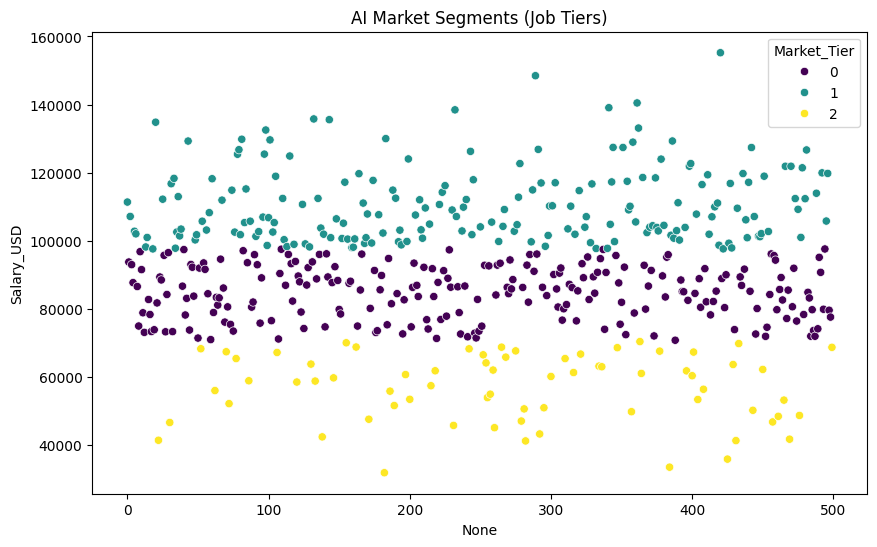

In [7]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
df['Market_Tier'] = kmeans.fit_predict(df[['Salary_USD']])

plt.figure(figsize=(10, 6))
sns.scatterplot(x=df.index, y=df['Salary_USD'], hue=df['Market_Tier'], palette='viridis')
plt.title('AI Market Segments (Job Tiers)')
plt.show()

**Finding the "Winners" (Feature Importance)**

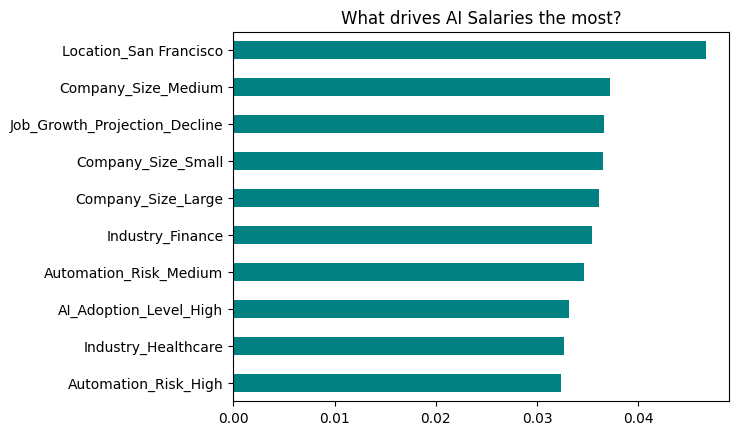

In [8]:

importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values().tail(10).plot(kind='barh', color='teal')
plt.title('What drives AI Salaries the most?')
plt.show()

**Final Conclusion**

**Conclusion**: This project successfully analyzed the AI job market. Using Random Forest, I identified the main factors driving high salaries. By using K-Means Clustering, I categorized the market into three distinct tiers, showing that AI Adoption and Industry are more important than job titles in determining compensation.